In [1]:
# Supermarket Sales Data Analysis

## Problem Statement

#Retail businesses generate large amounts of transaction data daily. Analyzing this data helps identify sales trends, customer purchasing behavior, preferred payment methods, branch performance, and product line profitability.

#This project performs Data Cleaning, Preprocessing, Exploratory Data Analysis (EDA), and Visualization on the Supermarket Sales dataset to derive meaningful business insights and support data-driven decision making.

## Objectives

#- Understand dataset structure
#- Perform data cleaning
#- Conduct exploratory data analysis
#- Generate visualizations
#- Extract business insights
#- Support business decision making

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8,5)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [3]:

#Load Dataset
df = pd.read_csv("marketsales.csv")

print("Dataset Loaded Successfully")
df.head()

Dataset Loaded Successfully


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [4]:
print("Rows and Columns:", df.shape)# Dataset Overview

print("\nRows:", df.shape[0])
print("Columns:", df.shape[1])

Rows and Columns: (1000, 17)

Rows: 1000
Columns: 17


In [5]:
df.columns.tolist()

['Invoice ID',
 'Branch',
 'City',
 'Customer type',
 'Gender',
 'Product line',
 'Unit price',
 'Quantity',
 'Tax 5%',
 'Total',
 'Date',
 'Time',
 'Payment',
 'cogs',
 'gross margin percentage',
 'gross income',
 'Rating']

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   str    
 1   Branch                   1000 non-null   str    
 2   City                     1000 non-null   str    
 3   Customer type            1000 non-null   str    
 4   Gender                   1000 non-null   str    
 5   Product line             1000 non-null   str    
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   str    
 11  Time                     1000 non-null   str    
 12  Payment                  1000 non-null   str    
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  1000 non-nu

In [7]:
df.describe()

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,0.000000,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905,49.650000,10.00000


In [8]:
# Data Cleaning
df.isnull().sum()
print("Duplicate Records:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

print("Dataset Shape After Removing Duplicates:")
print(df.shape)


Duplicate Records: 0
Dataset Shape After Removing Duplicates:
(1000, 17)


In [9]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df.columns

Index(['invoice_id', 'branch', 'city', 'customer_type', 'gender',
       'product_line', 'unit_price', 'quantity', 'tax_5%', 'total', 'date',
       'time', 'payment', 'cogs', 'gross_margin_percentage', 'gross_income',
       'rating'],
      dtype='str')

In [10]:
df["date"] = pd.to_datetime(df["date"])

df["time"] = pd.to_datetime(df["time"])

print("Date and Time Converted Successfully")

Date and Time Converted Successfully


C:\Users\Nishanth\AppData\Local\Temp\ipykernel_12380\2968185467.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"])


In [11]:
df["month"] = df["date"].dt.month_name()

df["day"] = df["date"].dt.day_name()

df["hour"] = df["time"].dt.hour

df.head()

,invoice_id,branch,city,customer_type,gender,product_line,unit_price,quantity,tax_5%,total,date,time,payment,cogs,gross_margin_percentage,gross_income,rating,month,day,hour
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,2026-06-11 13:08:00,Ewallet,522.83,4.761905,26.1415,9.1,January,Saturday,13
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,2026-06-11 10:29:00,Cash,76.40,4.761905,3.8200,9.6,March,Friday,10
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,2026-06-11 13:23:00,Credit card,324.31,4.761905,16.2155,7.4,March,Sunday,13
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,2026-06-11 20:33:00,Ewallet,465.76,4.761905,23.2880,8.4,January,Sunday,20
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,2026-06-11 10:37:00,Ewallet,604.17,4.761905,30.2085,5.3,February,Friday,10


In [12]:
# Unique Value Analysis
categorical_columns = [
    "branch",
    "city",
    "customer_type",
    "gender",
    "product_line",
    "payment"
]

for col in categorical_columns:
    print("\n" + "="*50)
    print(col.upper())
    print("="*50)
    print(df[col].value_counts())


BRANCH
branch
A    340
B    332
C    328
Name: count, dtype: int64

CITY
city
Yangon       340
Mandalay     332
Naypyitaw    328
Name: count, dtype: int64

CUSTOMER_TYPE
customer_type
Member    501
Normal    499
Name: count, dtype: int64

GENDER
gender
Female    501
Male      499
Name: count, dtype: int64

PRODUCT_LINE
product_line
Fashion accessories       178
Food and beverages        174
Electronic accessories    170
Sports and travel         166
Home and lifestyle        160
Health and beauty         152
Name: count, dtype: int64

PAYMENT
payment
Ewallet        345
Cash           344
Credit card    311
Name: count, dtype: int64


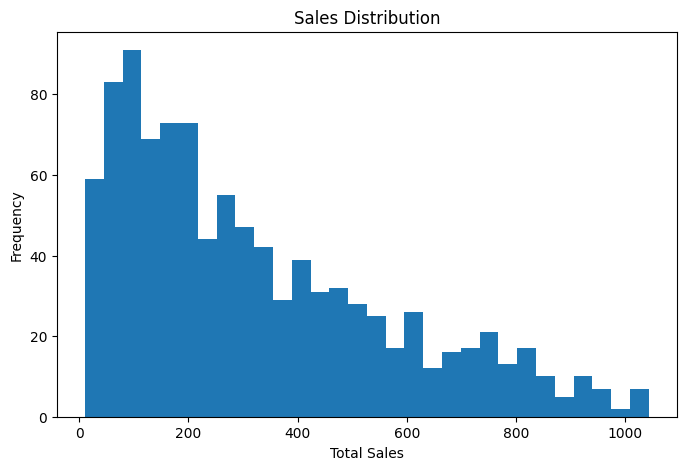

In [13]:
# Exploratory Data Analysis
plt.hist(df["total"], bins=30)

plt.title("Sales Distribution")
plt.xlabel("Total Sales")
plt.ylabel("Frequency")

plt.show()

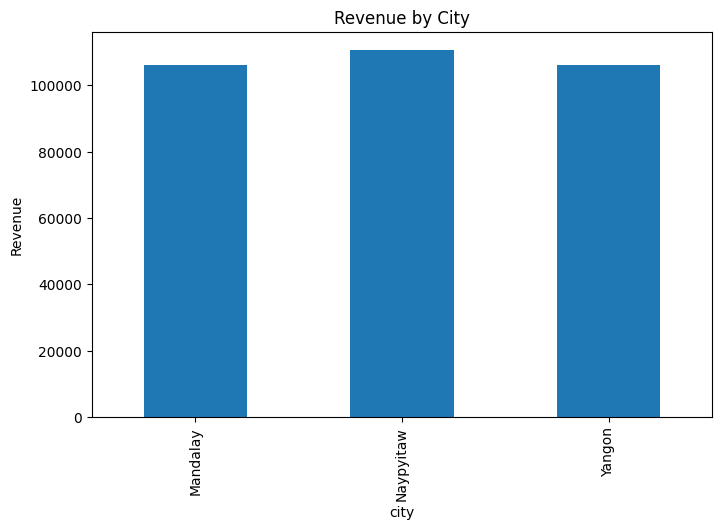

In [14]:
city_sales = df.groupby("city")["total"].sum()

city_sales.plot(kind="bar")

plt.title("Revenue by City")
plt.ylabel("Revenue")

plt.show()

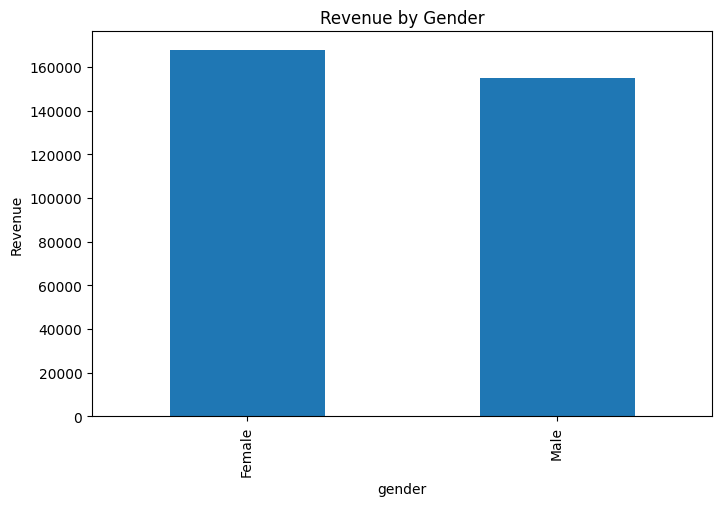

In [15]:
gender_sales = df.groupby("gender")["total"].sum()

gender_sales.plot(kind="bar")

plt.title("Revenue by Gender")
plt.ylabel("Revenue")

plt.show()

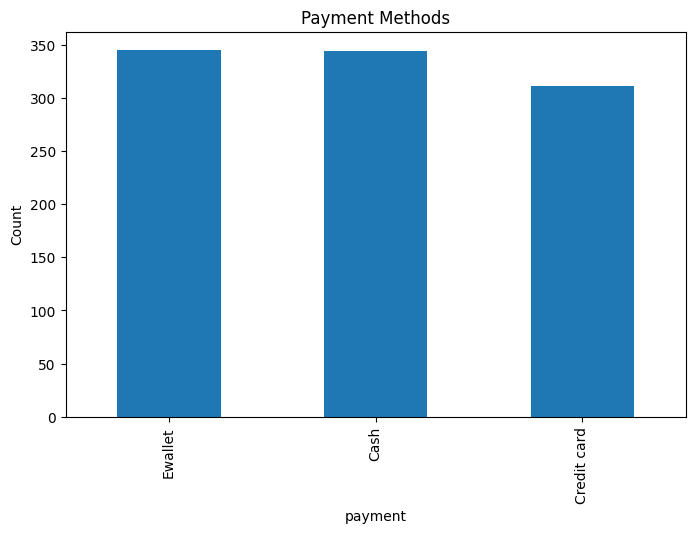

In [16]:
payment = df["payment"].value_counts()

payment.plot(kind="bar")

plt.title("Payment Methods")
plt.ylabel("Count")

plt.show()

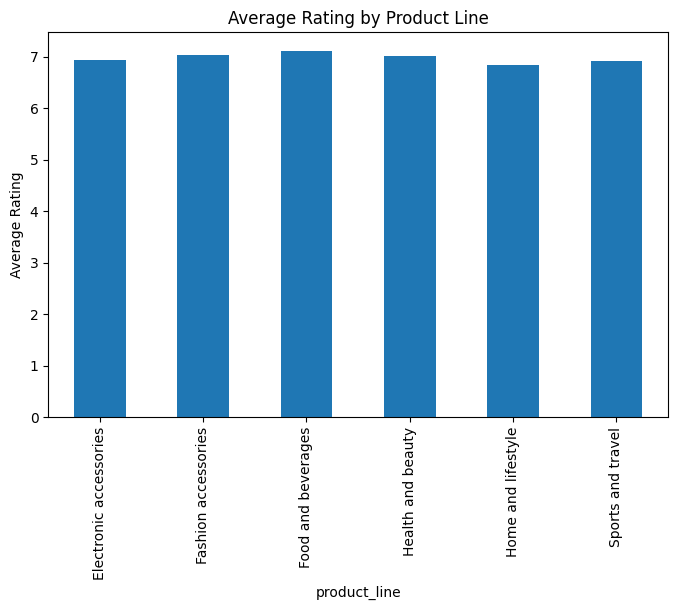

In [17]:
rating_avg = df.groupby("product_line")["rating"].mean()

rating_avg.plot(kind="bar")

plt.title("Average Rating by Product Line")
plt.ylabel("Average Rating")

plt.show()

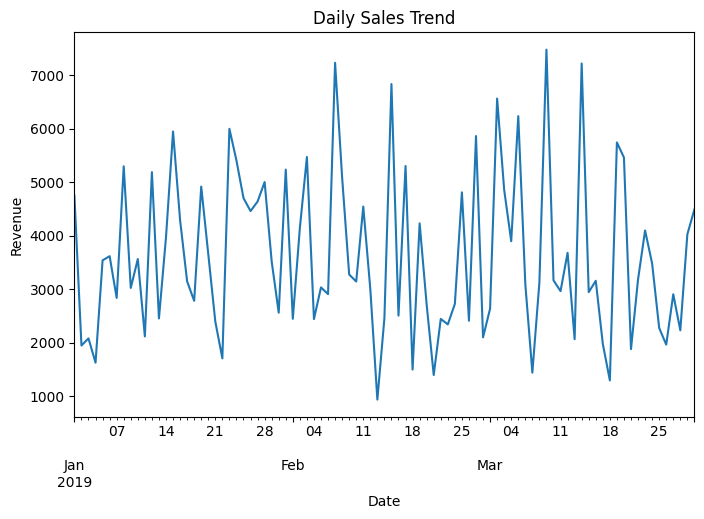

In [18]:
daily_sales = df.groupby("date")["total"].sum()

daily_sales.plot()

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.show()

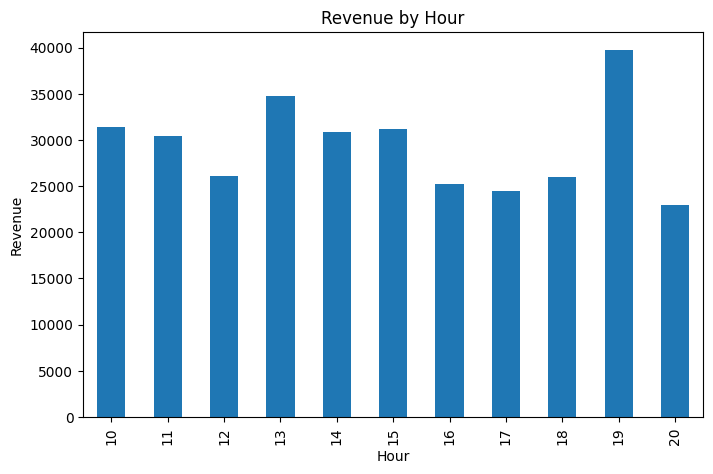

In [19]:
hourly_sales = df.groupby("hour")["total"].sum()

hourly_sales.plot(kind="bar")

plt.title("Revenue by Hour")
plt.xlabel("Hour")
plt.ylabel("Revenue")

plt.show()

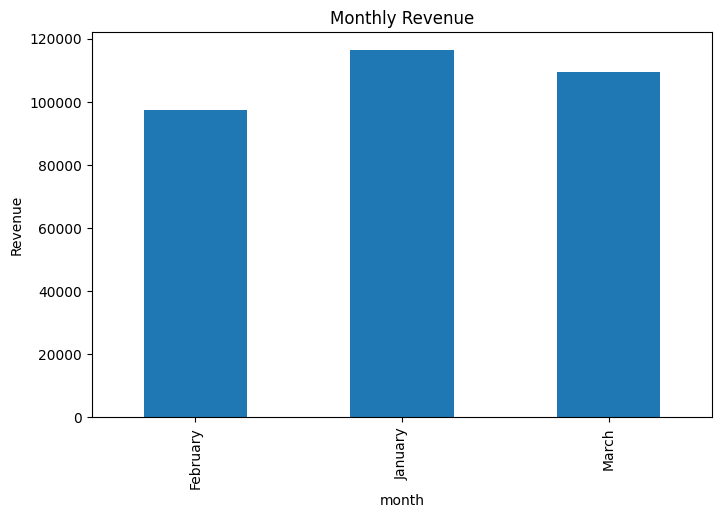

In [20]:
monthly_sales = df.groupby("month")["total"].sum()

monthly_sales.plot(kind="bar")

plt.title("Monthly Revenue")
plt.ylabel("Revenue")

plt.show()

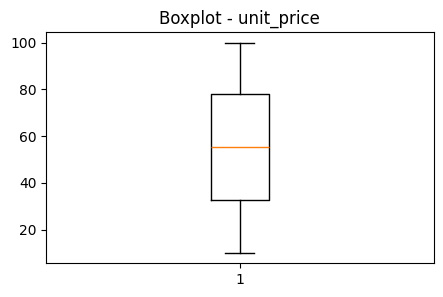

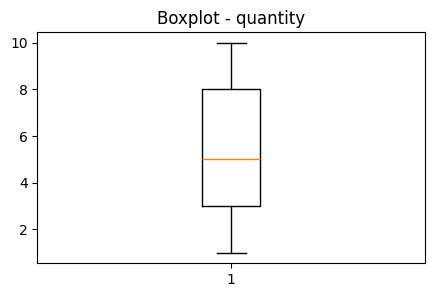

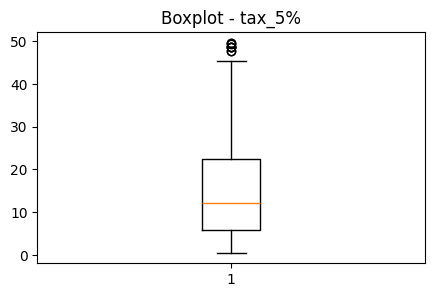

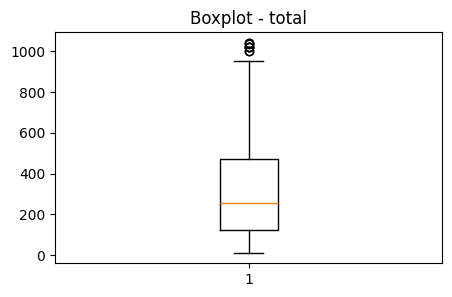

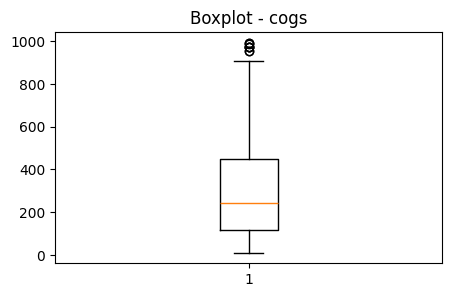

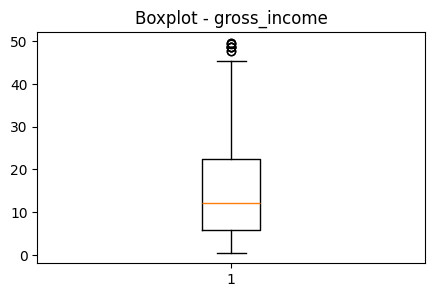

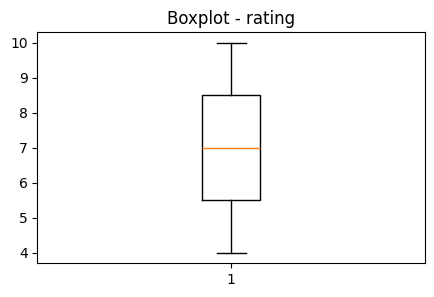

In [21]:
# Outlier Analysis
numeric_columns = [
    "unit_price",
    "quantity",
    "tax_5%",
    "total",
    "cogs",
    "gross_income",
    "rating"
]

for col in numeric_columns:
    
    plt.figure(figsize=(5,3))
    
    plt.boxplot(df[col])
    
    plt.title(f"Boxplot - {col}")
    
    plt.show()

In [22]:
# Correlation Analysis
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

corr

,unit_price,quantity,tax_5%,total,cogs,gross_margin_percentage,gross_income,rating,hour
unit_price,1.000000,0.010778,0.633962,0.633962,0.633962,NaN,0.633962,-0.008778,0.008242
quantity,0.010778,1.000000,0.705510,0.705510,0.705510,NaN,0.705510,-0.015815,-0.007317
tax_5%,0.633962,0.705510,1.000000,1.000000,1.000000,NaN,1.000000,-0.036442,-0.002770
total,0.633962,0.705510,1.000000,1.000000,1.000000,NaN,1.000000,-0.036442,-0.002770
cogs,0.633962,0.705510,1.000000,1.000000,1.000000,NaN,1.000000,-0.036442,-0.002770
gross_margin_percentage,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gross_income,0.633962,0.705510,1.000000,1.000000,1.000000,NaN,1.000000,-0.036442,-0.002770
rating,-0.008778,-0.015815,-0.036442,-0.036442,-0.036442,NaN,-0.036442,1.000000,-0.030588
hour,0.008242,-0.007317,-0.002770,-0.002770,-0.002770,NaN,-0.002770,-0.030588,1.000000


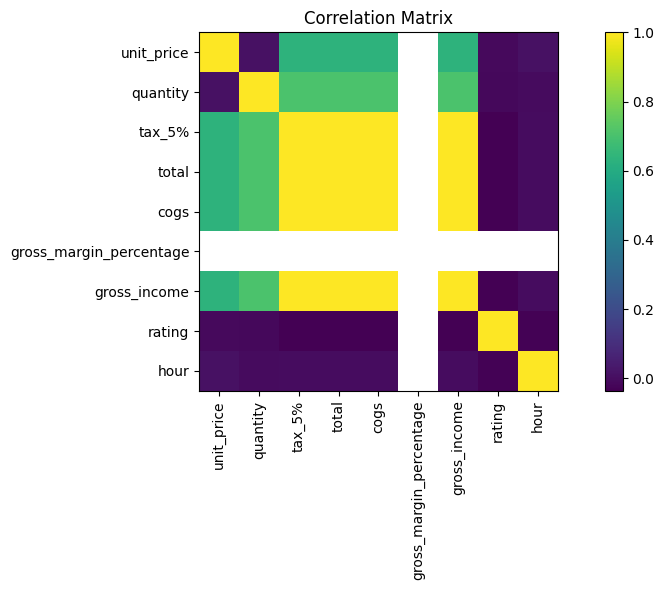

In [23]:
plt.figure(figsize=(10,6))

plt.imshow(corr)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

In [24]:
# Top Transactions
df.nlargest(
    10,
    "total"
)[
    [
        "invoice_id",
        "city",
        "product_line",
        "total"
    ]
]

,invoice_id,city,product_line,total
350,860-79-0874,Naypyitaw,Fashion accessories,1042.650
167,687-47-8271,Yangon,Fashion accessories,1039.290
557,283-26-5248,Naypyitaw,Food and beverages,1034.460
699,751-41-9720,Naypyitaw,Home and lifestyle,1023.750
996,303-96-2227,Mandalay,Home and lifestyle,1022.490
792,744-16-7898,Mandalay,Home and lifestyle,1022.385
422,271-88-8734,Naypyitaw,Fashion accessories,1020.705
166,234-65-2137,Naypyitaw,Home and lifestyle,1003.590
357,554-42-2417,Naypyitaw,Sports and travel,1002.120
429,325-77-6186,Yangon,Home and lifestyle,951.825


In [25]:
# Business Insights
print("Highest Revenue Branch:")
print(df.groupby("branch")["total"].sum().idxmax())

print("\nHighest Revenue City:")
print(df.groupby("city")["total"].sum().idxmax())

print("\nBest Product Line:")
print(df.groupby("product_line")["total"].sum().idxmax())

print("\nMost Used Payment Method:")
print(df["payment"].value_counts().idxmax())

print("\nHighest Rated Product Line:")
print(df.groupby("product_line")["rating"].mean().idxmax())

print("\nPeak Revenue Hour:")
print(df.groupby("hour")["total"].sum().idxmax())

Highest Revenue Branch:
C

Highest Revenue City:
Naypyitaw

Best Product Line:
Food and beverages

Most Used Payment Method:
Ewallet

Highest Rated Product Line:
Food and beverages

Peak Revenue Hour:
19


In [26]:
# Conclusion

#The Supermarket Sales dataset was successfully cleaned, processed, and analyzed.

#Key findings include:
#- Revenue distribution across branches and cities
#- Customer purchasing patterns
#- Product line performance
#- Payment preferences
#- Sales trends over time

#The analysis provides valuable insights that can help supermarket management improve operational efficiency, marketing strategies, and customer satisfaction.